# Exposure


In [6]:
##Import different packages
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import copy as cp
import pandas as pd
from scipy import sparse
import cartopy.crs as ccrs
from timeit import default_timer as timer
from os import mkdir, remove, rmdir
import geopandas as gpd

from climada.engine import Impact, ImpactCalc
from climada.entity import ImpactFunc,ImpactFuncSet

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import logging
from climada.util.config import LOGGER
LOGGER.setLevel(logging.ERROR)

##Load self-written, custom function definitions
from SL_bias_corr import *
from constants import *
from functions_projUncWS import *
idx = pd.IndexSlice

In [2]:
EU_countries = ['Belgium']

#Read metadat
ltpop_info = pd.read_csv('/Users/anne-sophiesimons/Desktop/Climate change projections paper/data/_metadata_countries_v1_2.csv',sep=',')
#Filter Belgium
ctrs_metadata = ltpop_info[ltpop_info["country_name"].isin(EU_countries)][["country_name","region_id","iso3"]]
ctrs_regids = ctrs_metadata.region_id.tolist()

#All LitPop regions for Belgium
BE_regids = ctrs_regids

#Generate LitPop data
from climada.entity import LitPop

#LitPop exponents
m, n = 1, 1
#Resolution in arc-seconds
res_exp = 30
exp_thres = 1

#Get the LitPop exposure for the different years
exp_BE_2000 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2000)
exp_BE_2001 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2001)
exp_BE_2002 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2002)
exp_BE_2003 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2003)
exp_BE_2004 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2004)
exp_BE_2005 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2005)
exp_BE_2006 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2006)
exp_BE_2007 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2007)
exp_BE_2008 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2008)
exp_BE_2009 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2009)
exp_BE_2010 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2010)
exp_BE_2011 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2011)
exp_BE_2012 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2012)
exp_BE_2013 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2013)
exp_BE_2014 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2014)
exp_BE_2015 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2015)
exp_BE_2016 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2016)
exp_BE_2017 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2017)
exp_BE_2018 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2018)
exp_BE_2019 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2019)
exp_BE_2020 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2020)
exp_BE_2021 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2021)
exp_BE_2022 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2022)
exp_BE_2023 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2023)
exp_BE_2024 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2024)
exp_BE_2025 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2025)

In [3]:
#Total exposure across whole Belgium
total_exposure_2000 = exp_BE_2000.gdf['value'].sum()
total_exposure_2001 = exp_BE_2001.gdf['value'].sum()
total_exposure_2002 = exp_BE_2002.gdf['value'].sum()
total_exposure_2003 = exp_BE_2003.gdf['value'].sum()
total_exposure_2004 = exp_BE_2004.gdf['value'].sum()
total_exposure_2005 = exp_BE_2005.gdf['value'].sum()
total_exposure_2006 = exp_BE_2006.gdf['value'].sum()
total_exposure_2007 = exp_BE_2007.gdf['value'].sum()
total_exposure_2008 = exp_BE_2008.gdf['value'].sum()
total_exposure_2009 = exp_BE_2009.gdf['value'].sum()
total_exposure_2010 = exp_BE_2010.gdf['value'].sum()
total_exposure_2011 = exp_BE_2011.gdf['value'].sum()
total_exposure_2012 = exp_BE_2012.gdf['value'].sum()
total_exposure_2013 = exp_BE_2013.gdf['value'].sum()
total_exposure_2014 = exp_BE_2014.gdf['value'].sum()
total_exposure_2015 = exp_BE_2015.gdf['value'].sum()
total_exposure_2016 = exp_BE_2016.gdf['value'].sum()
total_exposure_2017 = exp_BE_2017.gdf['value'].sum()
total_exposure_2018 = exp_BE_2018.gdf['value'].sum()
total_exposure_2019 = exp_BE_2019.gdf['value'].sum()
total_exposure_2020 = exp_BE_2020.gdf['value'].sum()
total_exposure_2021 = exp_BE_2021.gdf['value'].sum()
total_exposure_2022 = exp_BE_2022.gdf['value'].sum()
total_exposure_2023 = exp_BE_2023.gdf['value'].sum()
total_exposure_2024 = exp_BE_2024.gdf['value'].sum()
total_exposure_2025 = exp_BE_2025.gdf['value'].sum()


print(f"Totale LitPop exposure BE (2000): {total_exposure_2000:.2e} USD")
print(f"Totale LitPop exposure BE (2001): {total_exposure_2001:.2e} USD")
print(f"Totale LitPop exposure BE (2002): {total_exposure_2002:.2e} USD")
print(f"Totale LitPop exposure BE (2003): {total_exposure_2003:.2e} USD")
print(f"Totale LitPop exposure BE (2004): {total_exposure_2004:.2e} USD")
print(f"Totale LitPop exposure BE (2005): {total_exposure_2005:.2e} USD")
print(f"Totale LitPop exposure BE (2006): {total_exposure_2006:.2e} USD")
print(f"Totale LitPop exposure BE (2007): {total_exposure_2007:.2e} USD")
print(f"Totale LitPop exposure BE (2008): {total_exposure_2008:.2e} USD")
print(f"Totale LitPop exposure BE (2009): {total_exposure_2009:.2e} USD")
print(f"Totale LitPop exposure BE (2010): {total_exposure_2010:.2e} USD")
print(f"Totale LitPop exposure BE (2011): {total_exposure_2011:.2e} USD")
print(f"Totale LitPop exposure BE (2012): {total_exposure_2012:.2e} USD")
print(f"Totale LitPop exposure BE (2013): {total_exposure_2013:.2e} USD")
print(f"Totale LitPop exposure BE (2014): {total_exposure_2014:.2e} USD")
print(f"Totale LitPop exposure BE (2015): {total_exposure_2015:.2e} USD")
print(f"Totale LitPop exposure BE (2016): {total_exposure_2016:.2e} USD")
print(f"Totale LitPop exposure BE (2017): {total_exposure_2017:.2e} USD")
print(f"Totale LitPop exposure BE (2018): {total_exposure_2018:.2e} USD")
print(f"Totale LitPop exposure BE (2019): {total_exposure_2019:.2e} USD")
print(f"Totale LitPop exposure BE (2020): {total_exposure_2020:.2e} USD")
print(f"Totale LitPop exposure BE (2021): {total_exposure_2021:.2e} USD")
print(f"Totale LitPop exposure BE (2022): {total_exposure_2022:.2e} USD")
print(f"Totale LitPop exposure BE (2023): {total_exposure_2023:.2e} USD")
print(f"Totale LitPop exposure BE (2024): {total_exposure_2024:.2e} USD")
print(f"Totale LitPop exposure BE (2025): {total_exposure_2025:.2e} USD")

Totale LitPop exposure BE (2000): 1.57e+12 USD
Totale LitPop exposure BE (2001): 1.60e+12 USD
Totale LitPop exposure BE (2002): 1.62e+12 USD
Totale LitPop exposure BE (2003): 1.64e+12 USD
Totale LitPop exposure BE (2004): 1.67e+12 USD
Totale LitPop exposure BE (2005): 1.70e+12 USD
Totale LitPop exposure BE (2006): 1.73e+12 USD
Totale LitPop exposure BE (2007): 1.77e+12 USD
Totale LitPop exposure BE (2008): 1.80e+12 USD
Totale LitPop exposure BE (2009): 1.83e+12 USD
Totale LitPop exposure BE (2010): 1.86e+12 USD
Totale LitPop exposure BE (2011): 1.88e+12 USD
Totale LitPop exposure BE (2012): 1.91e+12 USD
Totale LitPop exposure BE (2013): 1.94e+12 USD
Totale LitPop exposure BE (2014): 1.97e+12 USD
Totale LitPop exposure BE (2015): 1.69e+12 USD
Totale LitPop exposure BE (2016): 1.74e+12 USD
Totale LitPop exposure BE (2017): 1.83e+12 USD
Totale LitPop exposure BE (2018): 1.99e+12 USD
Totale LitPop exposure BE (2019): 1.97e+12 USD
Totale LitPop exposure BE (2020): 1.94e+12 USD
Totale LitPop

In [7]:
#Get Belgium shapefile
bel_shp = '/Users/anne-sophiesimons/Documents/Data thesis/gadm41_BEL_0.shp'
bel = gpd.read_file(bel_shp)

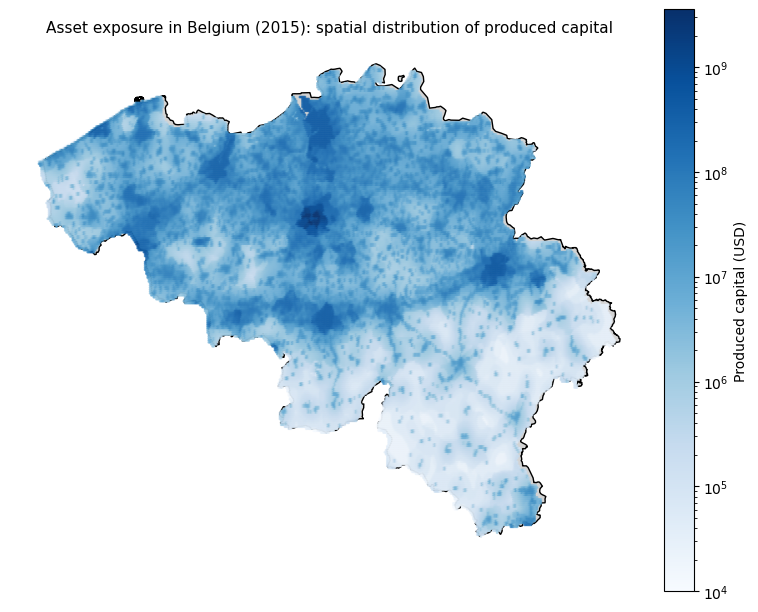

In [9]:
#Plot the LitPop exposure for 2015
import matplotlib.pyplot as plt
import matplotlib.colors as colors

vmin = 1e4
vmax = exp_BE_2015.gdf['value'].max()

fig, ax = plt.subplots(figsize=(8, 10))
bel.plot(ax=ax, color='lightgrey', edgecolor='black')
exp_BE_2010.gdf.plot(
    ax=ax,
    column='value',
    markersize=1,
    cmap='Blues',
    alpha=0.7,
    legend=True,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    legend_kwds={
        'label': 'Produced capital (USD)',
        'orientation': 'vertical',
        'shrink': 0.6,    
        'aspect': 20,    
        'pad': 0.02      
    }
)
plt.title('Asset exposure in Belgium (2015): spatial distribution of produced capital', fontsize=11)
plt.axis('off')
plt.tight_layout()
#Save plot
#plt.savefig('/Users/anne-sophiesimons/Documents/Data thesis/exposure_BE_2015.png', 
           # dpi=300, bbox_inches='tight')
plt.show()

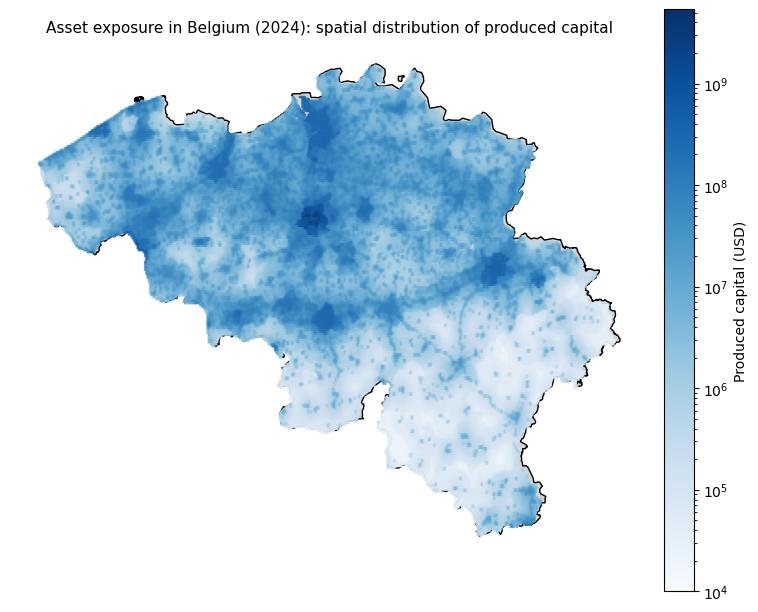

In [11]:
#Plot LitPop exposure for 2024
import matplotlib.pyplot as plt
import matplotlib.colors as colors

vmin = 1e4
vmax = exp_BE_2024.gdf['value'].max()

fig, ax = plt.subplots(figsize=(8, 10))
bel.plot(ax=ax, color='lightgrey', edgecolor='black')
exp_BE_2010.gdf.plot(
    ax=ax,
    column='value',
    markersize=1,
    cmap='Blues',
    alpha=0.7,
    legend=True,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    legend_kwds={
        'label': 'Produced capital (USD)',
        'orientation': 'vertical',
        'shrink': 0.6,  
        'aspect': 20,     
        'pad': 0.02       
    }
)
plt.title('Asset exposure in Belgium (2024): spatial distribution of produced capital', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig('/Users/anne-sophiesimons/Documents/Data thesis/exposure_BE_2024.png', 
            dpi=300, bbox_inches='tight')
plt.show()

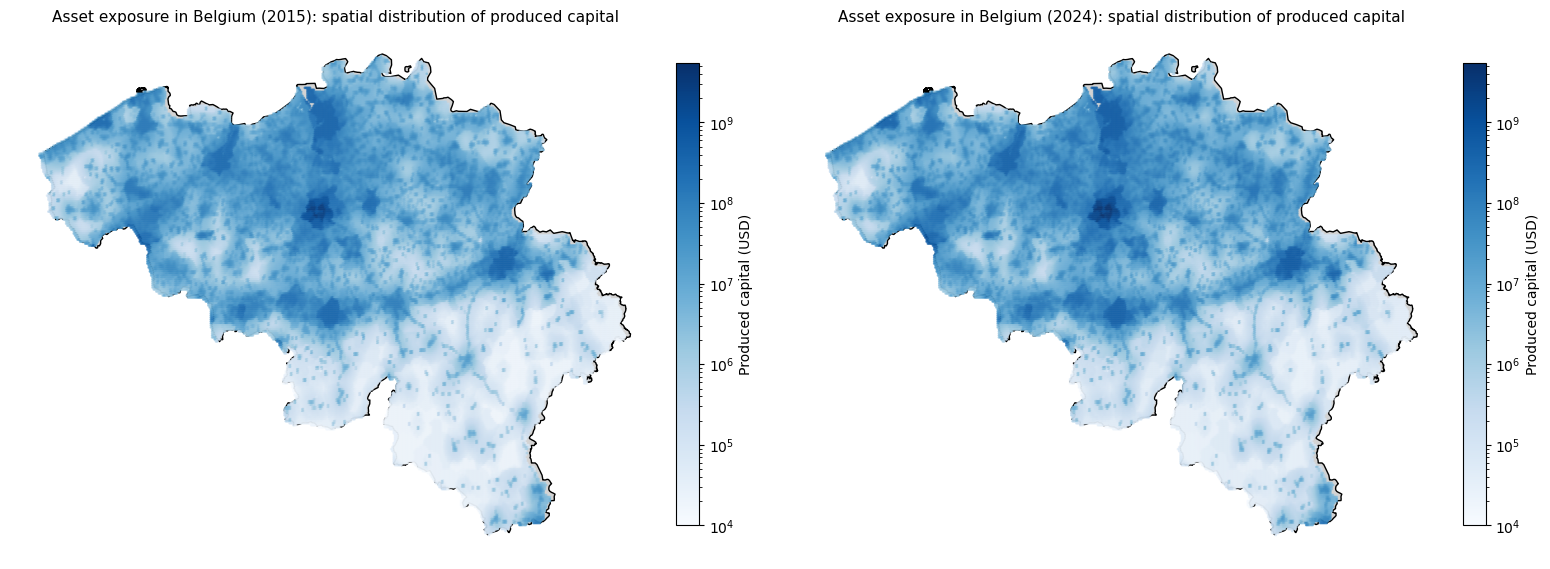

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

vmin = 1e4
vmax = max(exp_BE_2015.gdf['value'].max(), exp_BE_2024.gdf['value'].max())
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#Left plot: 2015
bel.plot(ax=axes[0], color='lightgrey', edgecolor='black')
exp_BE_2015.gdf.plot(
    ax=axes[0],
    column='value',
    markersize=1,
    cmap='Blues',
    alpha=0.7,
    legend=True,
    norm=norm,
    legend_kwds={
        'label': 'Produced capital (USD)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'aspect': 20,
        'pad': 0.02
    }
)
axes[0].set_title('Asset exposure in Belgium (2015): spatial distribution of produced capital', fontsize=11)
axes[0].axis('off')

#Right plot: 2024
bel.plot(ax=axes[1], color='lightgrey', edgecolor='black')
exp_BE_2024.gdf.plot(
    ax=axes[1],
    column='value',
    markersize=1,
    cmap='Blues',
    alpha=0.7,
    legend=True,
    norm=norm,
    legend_kwds={
        'label': 'Produced capital (USD)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'aspect': 20,
        'pad': 0.02
    }
)
axes[1].set_title('Asset exposure in Belgium (2024): spatial distribution of produced capital', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/Users/anne-sophiesimons/Documents/Data thesis/exposure_BE_2015_2024.png',
            dpi=300, bbox_inches='tight')
plt.show()